# Strict Raw-Feature V2 Ridge/Hybrid LinUCB Evaluation

This notebook evaluates the cleaned raw-feature V2 candidate sets using disjoint RidgeLinUCB and Hybrid RidgeLinUCB under binary and ordinal rewards. It also runs coefficient audits for the best disjoint and hybrid models, including clinical-signal views that filter out pure missingness/intercept features.


In [20]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [21]:
def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_feature_set_evaluation'
AUDIT_DIR = RESULTS_DIR / 'coefficient_audit'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)

Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation


In [22]:
from src.bandits.hybrid_linUCB import HybridRidgeLinUCB
from src.bandits.linUCB import RidgeLinUCB
from src.evaluation.coefficient_audit import (
    audit_bandit_coefficients,
    plot_top_coefficients,
    save_coefficient_audit,
)
from src.evaluation.feature_set_benchmark import (
    FINAL_FEATURE_SETS,
    FINAL_HYBRID_GRID,
    FINAL_RIDGE_GRID,
    REWARD_SCHEMES_TO_COMPARE,
    available_final_feature_sets,
    classwise_metrics,
    confusion_table,
    evaluate_feature_set_grid_for_rewards,
    evaluate_hybrid_feature_set_grid_for_rewards,
    list_feature_sets,
    load_v2_assets,
    plot_feature_set_accuracy,
    save_benchmark_outputs,
    static_policy_summary,
    summarize_error_metrics,
)

## 1. Load cleaned V2 assets

In [23]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
feature_set_names = available_final_feature_sets(feature_sets, FINAL_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('V2 preprocessing output:', preprocess_output_dir)
print('Active feature sets:', feature_set_names)
print('Reward schemes:', REWARD_SCHEMES_TO_COMPARE)

list_feature_sets(feature_sets)

V2 modeling table: (5528, 307)
V2 preprocessing output: /Users/dhillo/Garage/codeComplete/full measure/warfarin/output/preprocess_v2
Active feature sets: ['v2_strict_regression_hw_full_dummies', 'v2_strict_knn_hw_full_dummies']
Reward schemes: ['binary', 'ordinal']


,feature_set,n_features
0,v2_strict_regression_hw_full_dummies,295
1,v2_strict_knn_hw_full_dummies,295


## 2. Static baseline checks

Static baselines do not learn online, but the fixed-medium policy is useful as a sanity check.

In [24]:
static_baselines = static_policy_summary(df_v2, feature_set_names)
static_baselines.to_csv(RESULTS_DIR / 'static_baseline_summary.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,mean_ordinal_reward,n_correct,n_total
1,v2_strict_knn_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
0,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528


## 3. Disjoint RidgeLinUCB final grid

In [25]:
SEEDS = range(5)
RIDGE_ALPHAS = FINAL_RIDGE_GRID['alphas']
RIDGE_LAMBDAS = FINAL_RIDGE_GRID['lambda_regs']

ridge_summary, ridge_results, ridge_scale_stats = evaluate_feature_set_grid_for_rewards(
    df=df_v2,
    feature_sets=feature_sets,
    linucb_cls=RidgeLinUCB,
    feature_set_names=feature_set_names,
    alphas=RIDGE_ALPHAS,
    lambda_regs=RIDGE_LAMBDAS,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ridge_summary['algorithm_family'] = 'RidgeLinUCB'
ridge_summary['config_name'] = ridge_summary['algorithm']
ridge_results['algorithm_family'] = 'RidgeLinUCB'
ridge_results['config_name'] = ridge_results['algorithm']

ridge_summary.head(20)

RidgeLinUCB feature set: v2_strict_regression_hw_full_dummies (295 features), reward=binary
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  RidgeLinUCB(alpha=0.025, lambda=5.0)
  RidgeLinUCB(alpha=0.025, lambda=10.0)
  RidgeLinUCB(alpha=0.025, lambda=20.0)
  RidgeLinUCB(alpha=0.05, lambda=5.0)
  RidgeLinUCB(alpha=0.05, lambda=10.0)
  RidgeLinUCB(alpha=0.05, lambda=20.0)
  RidgeLinUCB(alpha=0.1, lambda=5.0)
  RidgeLinUCB(alpha=0.1, lambda=10.0)
  RidgeLinUCB(alpha=0.1, lambda=20.0)
RidgeLinUCB feature set: v2_strict_knn_hw_full_dummies (295 features), reward=binary
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  RidgeLinUCB(alp

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,alpha,lambda_reg,n_features,algorithm_family,config_name
30,"RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,5,0.683466,0.003793,0.681331,0.003597,1761.6,19.882153,0.316534,...,17.427475,0.003325,0.020316,0.020616,v2_strict_regression_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)"
31,"RidgeLinUCB(alpha=0.05, lambda=10.0)",ordinal,5,0.682742,0.003371,0.679993,0.003167,1769.0,17.507141,0.317258,...,15.345686,0.002955,0.017636,0.017636,v2_strict_regression_hw_full_dummies,0.050,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.05, lambda=10.0)"
32,"RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,5,0.682706,0.003003,0.679812,0.002826,1770.0,15.620499,0.317294,...,13.691971,0.002632,0.023145,0.023211,v2_strict_regression_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)"
0,"RidgeLinUCB(alpha=0.025, lambda=10.0)",binary,5,0.682706,0.003797,0.682706,0.003797,1754.0,20.988092,0.317294,...,18.396874,0.003328,0.024774,0.024774,v2_strict_regression_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)"
33,"RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,5,0.682055,0.003781,0.679378,0.003898,1772.4,21.547622,0.317945,...,18.887323,0.003314,0.015162,0.014541,v2_strict_knn_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)"
34,"RidgeLinUCB(alpha=0.01, lambda=10.0)",ordinal,5,0.681946,0.000728,0.679486,0.000605,1771.8,3.346640,0.318054,...,2.933459,0.000638,0.020011,0.020949,v2_strict_regression_hw_full_dummies,0.010,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.01, lambda=10.0)"
1,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.681874,0.003704,0.681874,0.003704,1758.6,20.476816,0.318126,...,17.948721,0.003247,0.022085,0.022085,v2_strict_knn_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)"
2,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.681802,0.003609,0.681802,0.003609,1759.0,19.949937,0.318198,...,17.486891,0.003163,0.023702,0.023702,v2_strict_regression_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)"
3,"RidgeLinUCB(alpha=0.05, lambda=10.0)",binary,5,0.681512,0.003337,0.681512,0.003337,1760.6,18.447222,0.318488,...,16.169703,0.002925,0.022057,0.022057,v2_strict_regression_hw_full_dummies,0.050,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.05, lambda=10.0)"
35,"RidgeLinUCB(alpha=0.1, lambda=5.0)",ordinal,5,0.681078,0.003172,0.676990,0.003285,1785.6,18.160396,0.318922,...,15.918289,0.002781,0.021161,0.022015,v2_strict_knn_hw_full_dummies,0.100,5.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=5.0)"


## 4. Hybrid RidgeLinUCB final grid

Hybrid RidgeLinUCB keeps per-arm ridge models and adds a shared ordinal patient-feature component. This lets low/high dose arms borrow signal without using pharmacogenetic formula outputs.

In [26]:
print('Hybrid grid:')
for row in FINAL_HYBRID_GRID:
    print(row)

hybrid_summary, hybrid_results, hybrid_scale_stats = evaluate_hybrid_feature_set_grid_for_rewards(
    df=df_v2,
    feature_sets=feature_sets,
    hybrid_cls=HybridRidgeLinUCB,
    feature_set_names=feature_set_names,
    param_grid=FINAL_HYBRID_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

hybrid_summary.head(20)

Hybrid grid:
{'alpha': 0.0, 'lambda_arm': 10.0, 'lambda_shared': 10.0, 'alpha_shared': 0.0, 'shared_weight': 0.5}
{'alpha': 0.0, 'lambda_arm': 10.0, 'lambda_shared': 20.0, 'alpha_shared': 0.0, 'shared_weight': 0.5}
{'alpha': 0.01, 'lambda_arm': 10.0, 'lambda_shared': 10.0, 'alpha_shared': 0.01, 'shared_weight': 0.5}
{'alpha': 0.01, 'lambda_arm': 10.0, 'lambda_shared': 20.0, 'alpha_shared': 0.01, 'shared_weight': 0.5}
{'alpha': 0.025, 'lambda_arm': 10.0, 'lambda_shared': 10.0, 'alpha_shared': 0.025, 'shared_weight': 0.5}
{'alpha': 0.01, 'lambda_arm': 20.0, 'lambda_shared': 10.0, 'alpha_shared': 0.01, 'shared_weight': 0.5}
{'alpha': 0.01, 'lambda_arm': 10.0, 'lambda_shared': 10.0, 'alpha_shared': 0.01, 'shared_weight': 1.0}
{'alpha': 0.025, 'lambda_arm': 10.0, 'lambda_shared': 20.0, 'alpha_shared': 0.025, 'shared_weight': 1.0}
Hybrid RidgeLinUCB feature set: v2_strict_regression_hw_full_dummies (295 features), reward=binary
  HybridRidgeLinUCB(alpha=0, lambda_arm=10, lambda_shared=10, al

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,alpha,lambda_arm,lambda_shared,alpha_shared,shared_weight
16,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.683611,0.003986,0.679161,0.003960,1773.6,21.892921,0.316389,...,0.022904,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",295,0.000,10.0,10.0,0.000,0.5
17,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.682996,0.002112,0.679088,0.002413,1774.0,13.341664,0.317004,...,0.022722,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",295,0.000,10.0,20.0,0.000,0.5
18,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=20, l...",ordinal,5,0.681114,0.003974,0.677315,0.004108,1783.8,22.709029,0.318886,...,0.029029,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=20, l...",295,0.010,20.0,10.0,0.010,0.5
19,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",ordinal,5,0.680970,0.005723,0.676881,0.006072,1786.2,33.566352,0.319030,...,0.018345,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",295,0.010,10.0,20.0,0.010,0.5
20,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.680753,0.002107,0.676664,0.002069,1787.4,11.436783,0.319247,...,0.018261,v2_strict_knn_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",295,0.000,10.0,20.0,0.000,0.5
21,"HybridRidgeLinUCB(alpha=0.025, lambda_arm=10, ...",ordinal,5,0.680463,0.005399,0.675724,0.005924,1792.6,32.745992,0.319537,...,0.027829,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.025, lambda_arm=10, ...",295,0.025,10.0,10.0,0.025,0.5
22,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",ordinal,5,0.680427,0.004373,0.676122,0.004428,1790.4,24.480605,0.319573,...,0.019733,v2_strict_knn_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",295,0.010,10.0,20.0,0.010,0.5
23,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",ordinal,5,0.680391,0.005974,0.675977,0.006171,1791.2,34.113047,0.319609,...,0.025836,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=10, l...",295,0.010,10.0,10.0,0.010,0.5
24,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.679740,0.006920,0.675181,0.007020,1795.6,38.804639,0.320260,...,0.018277,v2_strict_knn_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",295,0.000,10.0,10.0,0.000,0.5
25,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=20, l...",ordinal,5,0.679450,0.005348,0.675253,0.005319,1795.2,29.405782,0.320550,...,0.027045,v2_strict_knn_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0.01, lambda_arm=20, l...",295,0.010,20.0,10.0,0.010,0.5


## 5. Save combined Ridge/Hybrid metrics

In [27]:
ridge_hybrid_summary = pd.concat([ridge_summary, hybrid_summary], ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)
ridge_hybrid_results = pd.concat([ridge_results, hybrid_results], ignore_index=True)
ridge_hybrid_scale_stats = pd.concat([ridge_scale_stats, hybrid_scale_stats], ignore_index=True)

ridge_hybrid_error_summary = summarize_error_metrics(ridge_hybrid_results)
ridge_hybrid_classwise = classwise_metrics(ridge_hybrid_results)
ridge_hybrid_confusion_true = confusion_table(ridge_hybrid_results, normalize='true')
ridge_hybrid_confusion_counts = confusion_table(ridge_hybrid_results, normalize=None)

written = save_benchmark_outputs(
    RESULTS_DIR,
    ridge_hybrid_leaderboard=ridge_hybrid_summary,
    ridge_hybrid_scale_stats=ridge_hybrid_scale_stats,
    ridge_hybrid_error_summary=ridge_hybrid_error_summary,
    ridge_hybrid_classwise=ridge_hybrid_classwise,
    ridge_hybrid_confusion_true_normalized=ridge_hybrid_confusion_true,
    ridge_hybrid_confusion_counts=ridge_hybrid_confusion_counts,
    ridge_feature_set_summary=ridge_summary,
    hybrid_feature_set_summary=hybrid_summary,
    static_baseline_summary=static_baselines,
    save_step_results=False,
)
written

{'ridge_hybrid_leaderboard': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_leaderboard.csv',
 'ridge_hybrid_scale_stats': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_scale_stats.csv',
 'ridge_hybrid_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_error_summary.csv',
 'ridge_hybrid_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_classwise.csv',
 'ridge_hybrid_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_confusion_true_normalized.csv',
 'ridge_hybrid_confusion_counts': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_hybrid_confusion_counts.csv',
 'ridge_feature_set_summary': '/Users/dhillo/Garage/code

## 6. Leaderboard and diagnostics

In [28]:
ridge_hybrid_summary.sort_values('final_accuracy_mean', ascending=False).head(25)

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,feature_set,alpha,lambda_reg,n_features,algorithm_family,config_name,lambda_arm,lambda_shared,alpha_shared,shared_weight
60,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.683611,0.003986,0.679161,0.003960,1773.6,21.892921,0.316389,...,v2_strict_regression_hw_full_dummies,0.000,NaN,295,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",10.0,10.0,0.000,0.5
0,"RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,5,0.683466,0.003793,0.681331,0.003597,1761.6,19.882153,0.316534,...,v2_strict_regression_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)",NaN,NaN,NaN,NaN
61,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,5,0.682996,0.002112,0.679088,0.002413,1774.0,13.341664,0.317004,...,v2_strict_regression_hw_full_dummies,0.000,NaN,295,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",10.0,20.0,0.000,0.5
1,"RidgeLinUCB(alpha=0.05, lambda=10.0)",ordinal,5,0.682742,0.003371,0.679993,0.003167,1769.0,17.507141,0.317258,...,v2_strict_regression_hw_full_dummies,0.050,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.05, lambda=10.0)",NaN,NaN,NaN,NaN
3,"RidgeLinUCB(alpha=0.025, lambda=10.0)",binary,5,0.682706,0.003797,0.682706,0.003797,1754.0,20.988092,0.317294,...,v2_strict_regression_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)",NaN,NaN,NaN,NaN
2,"RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,5,0.682706,0.003003,0.679812,0.002826,1770.0,15.620499,0.317294,...,v2_strict_regression_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)",NaN,NaN,NaN,NaN
4,"RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,5,0.682055,0.003781,0.679378,0.003898,1772.4,21.547622,0.317945,...,v2_strict_knn_hw_full_dummies,0.025,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)",NaN,NaN,NaN,NaN
5,"RidgeLinUCB(alpha=0.01, lambda=10.0)",ordinal,5,0.681946,0.000728,0.679486,0.000605,1771.8,3.346640,0.318054,...,v2_strict_regression_hw_full_dummies,0.010,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.01, lambda=10.0)",NaN,NaN,NaN,NaN
6,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.681874,0.003704,0.681874,0.003704,1758.6,20.476816,0.318126,...,v2_strict_knn_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)",NaN,NaN,NaN,NaN
7,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.681802,0.003609,0.681802,0.003609,1759.0,19.949937,0.318198,...,v2_strict_regression_hw_full_dummies,0.100,10.0,295,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)",NaN,NaN,NaN,NaN


In [29]:
ridge_hybrid_error_summary.sort_values('accuracy_mean', ascending=False).head(25)

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,alpha,lambda_reg,lambda_arm,lambda_shared,alpha_shared,...,mean_regret_mean,mean_regret_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,mean_reward_ci95,severe_error_rate_ci95
47,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...","HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,0.000,NaN,10.0,10.0,0.000,...,0.320839,0.003960,0.004450,0.000303,0.311939,0.182634,0.133755,0.003494,0.003471,0.000265
75,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)","RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,0.025,10.0,NaN,NaN,NaN,...,0.318669,0.003597,0.002135,0.000592,0.314399,0.161795,0.154740,0.003325,0.003153,0.000519
49,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...","HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,0.000,NaN,10.0,20.0,0.000,...,0.320912,0.002413,0.003907,0.000552,0.313097,0.184515,0.132489,0.001851,0.002116,0.000484
81,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.05, lambda=10.0)","RidgeLinUCB(alpha=0.05, lambda=10.0)",ordinal,0.050,10.0,NaN,NaN,NaN,...,0.320007,0.003167,0.002750,0.000549,0.314508,0.161939,0.155318,0.002955,0.002776,0.000481
74,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)","RidgeLinUCB(alpha=0.025, lambda=10.0)",binary,0.025,10.0,NaN,NaN,NaN,...,0.317294,0.003797,0.003220,0.000578,0.314074,0.166932,0.150362,0.003328,0.003328,0.000506
87,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)","RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,0.100,10.0,NaN,NaN,NaN,...,0.320188,0.002826,0.002894,0.000256,0.314399,0.161577,0.155716,0.002632,0.002477,0.000224
29,v2_strict_knn_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.025, lambda=10.0)","RidgeLinUCB(alpha=0.025, lambda=10.0)",ordinal,0.025,10.0,NaN,NaN,NaN,...,0.320622,0.003898,0.002677,0.000236,0.315268,0.163061,0.154884,0.003314,0.003417,0.000207
69,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.01, lambda=10.0)","RidgeLinUCB(alpha=0.01, lambda=10.0)",ordinal,0.010,10.0,NaN,NaN,NaN,...,0.320514,0.000605,0.002460,0.000660,0.315593,0.164436,0.153618,0.000638,0.000531,0.000578
40,v2_strict_knn_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)","RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.100,10.0,NaN,NaN,NaN,...,0.318126,0.003704,0.004414,0.001462,0.313712,0.161397,0.156729,0.003247,0.003247,0.001281
86,v2_strict_regression_hw_full_dummies,RidgeLinUCB,"RidgeLinUCB(alpha=0.1, lambda=10.0)","RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.100,10.0,NaN,NaN,NaN,...,0.318198,0.003609,0.003654,0.000450,0.314544,0.164001,0.154197,0.003163,0.003163,0.000395


In [30]:
best = ridge_hybrid_summary.iloc[0]
best_filter = (
    (ridge_hybrid_classwise['feature_set'] == best['feature_set'])
    & (ridge_hybrid_classwise['algorithm_family'] == best['algorithm_family'])
    & (ridge_hybrid_classwise['config_name'] == best['config_name'])
    & (ridge_hybrid_classwise['reward_scheme'] == best['reward_scheme'])
)
ridge_hybrid_classwise.loc[best_filter].sort_values('class_id')

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,alpha,lambda_reg,lambda_arm,lambda_shared,alpha_shared,...,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
141,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...","HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,0.0,NaN,10.0,10.0,0.0,...,5,0.617832,0.003953,0.615251,0.012053,0.616487,0.006358,1495.0,0.010565,0.005573
142,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...","HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,0.0,NaN,10.0,10.0,0.0,...,5,0.726333,0.008844,0.786931,0.015262,0.755276,0.003751,3382.0,0.013378,0.003288
143,v2_strict_regression_hw_full_dummies,Hybrid RidgeLinUCB,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...","HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",ordinal,0.0,NaN,10.0,10.0,0.0,...,5,0.529109,0.017891,0.303840,0.072915,0.381906,0.058982,651.0,0.063913,0.051700


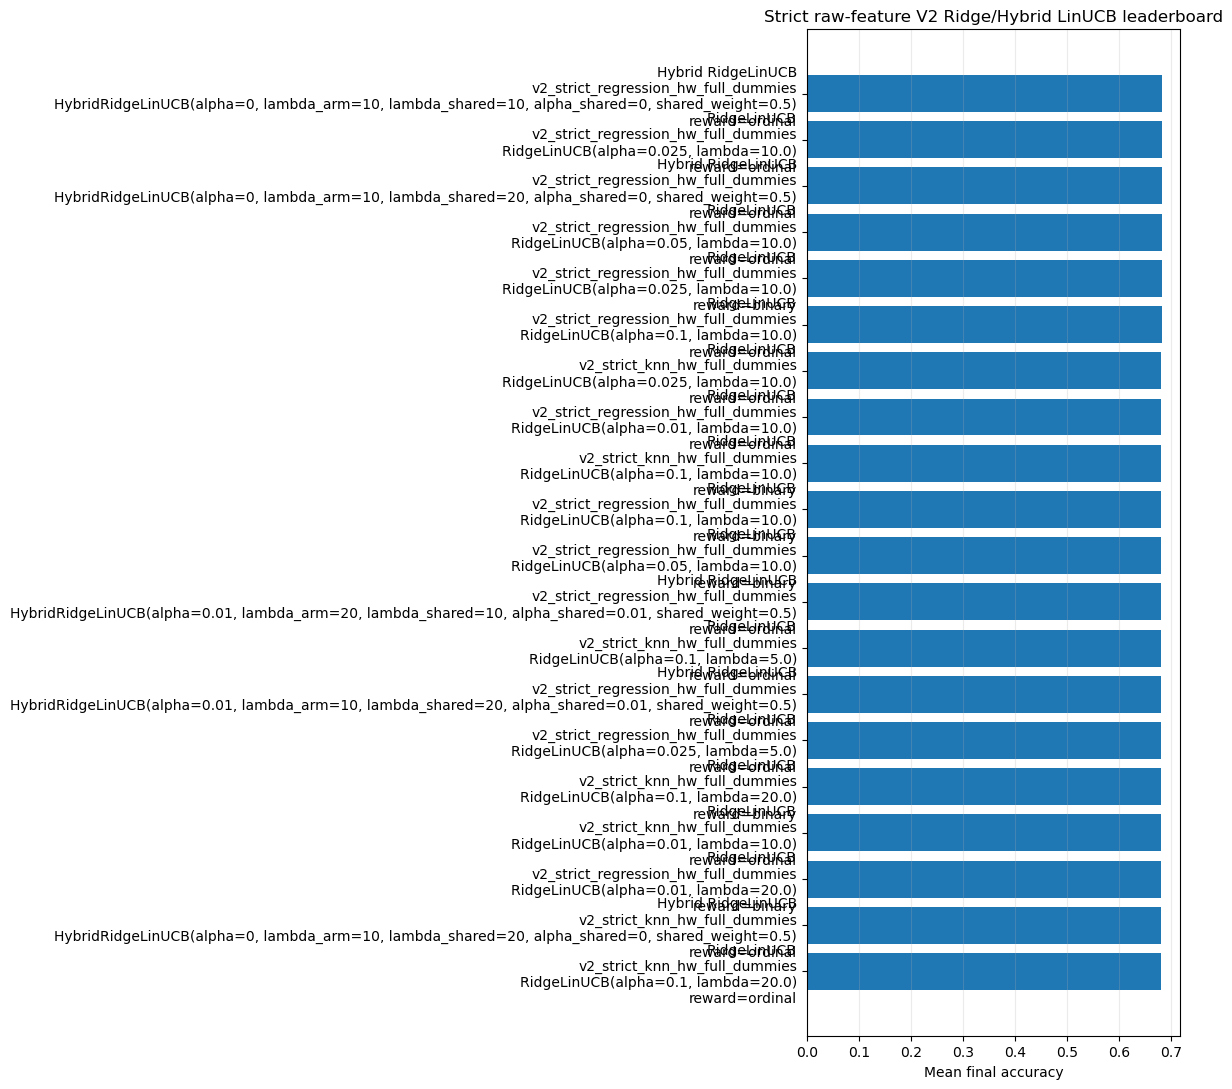

In [31]:
fig, ax = plot_feature_set_accuracy(
    ridge_hybrid_summary,
    top_n=20,
    title='Strict raw-feature V2 Ridge/Hybrid LinUCB leaderboard',
)
fig.savefig(RESULTS_DIR / 'clean_v2_ridge_hybrid_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Reward comparison checkpoint

The leaderboard uses exact bucket accuracy for both binary and ordinal rewards. Check `final_reward_mean`, low/high recall, and severe-error rates before deciding whether ordinal reward is genuinely better.

In [32]:
comparison_cols = [
    'algorithm_family', 'reward_scheme', 'feature_set', 'config_name',
    'final_accuracy_mean', 'final_accuracy_ci95',
    'final_reward_mean',
    'late_accuracy_mean', 'final_regret_mean',
]
ridge_hybrid_summary[comparison_cols].sort_values('final_accuracy_mean', ascending=False).head(30)

,algorithm_family,reward_scheme,feature_set,config_name,final_accuracy_mean,final_accuracy_ci95,final_reward_mean,late_accuracy_mean,final_regret_mean
60,Hybrid RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",0.683611,0.003494,0.679161,0.7032,1773.6
0,RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.025, lambda=10.0)",0.683466,0.003325,0.681331,0.6968,1761.6
61,Hybrid RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",0.682996,0.001851,0.679088,0.6956,1774.0
1,RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.05, lambda=10.0)",0.682742,0.002955,0.679993,0.6944,1769.0
3,RidgeLinUCB,binary,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.025, lambda=10.0)",0.682706,0.003328,0.682706,0.6884,1754.0
2,RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.682706,0.002632,0.679812,0.6932,1770.0
4,RidgeLinUCB,ordinal,v2_strict_knn_hw_full_dummies,"RidgeLinUCB(alpha=0.025, lambda=10.0)",0.682055,0.003314,0.679378,0.6928,1772.4
5,RidgeLinUCB,ordinal,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.681946,0.000638,0.679486,0.6892,1771.8
6,RidgeLinUCB,binary,v2_strict_knn_hw_full_dummies,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.681874,0.003247,0.681874,0.7016,1758.6
7,RidgeLinUCB,binary,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.681802,0.003163,0.681802,0.6972,1759.0


## 8. Coefficient audit for best disjoint and hybrid RidgeLinUCB

This section fits one final online pass for the best disjoint RidgeLinUCB and best Hybrid RidgeLinUCB configurations, then saves top coefficients, low/high-vs-medium contrasts, feature-group summaries, and clinical-signal views that exclude missingness/intercept features.


In [33]:
def ridge_factory_from_row(row):
    return lambda n_arms, n_features: RidgeLinUCB(
        alpha=float(row['alpha']),
        n_arms=n_arms,
        n_features=n_features,
        lambda_reg=float(row['lambda_reg']),
    )


def hybrid_factory_from_row(row):
    return lambda n_arms, n_features: HybridRidgeLinUCB(
        alpha=float(row['alpha']),
        n_arms=n_arms,
        n_features=n_features,
        lambda_arm=float(row['lambda_arm']),
        lambda_shared=float(row['lambda_shared']),
        alpha_shared=float(row['alpha_shared']),
        shared_weight=float(row['shared_weight']),
    )


best_ridge = ridge_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]
best_hybrid = hybrid_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]

audit_specs = [
    ('best_ridge_linucb', best_ridge, ridge_factory_from_row(best_ridge), 'effective'),
    ('best_hybrid_ridge_linucb', best_hybrid, hybrid_factory_from_row(best_hybrid), 'effective'),
]

audits = {}
for prefix, row, factory, coefficient_mode in audit_specs:
    audit = audit_bandit_coefficients(
        bandit_factory=factory,
        df=df_v2,
        feature_sets=feature_sets,
        feature_set_name=row['feature_set'],
        algorithm=row['config_name'],
        seed=0,
        reward_scheme=row['reward_scheme'],
        standardize=True,
        coefficient_mode=coefficient_mode,
        top_n=30,
    )
    save_coefficient_audit(AUDIT_DIR, prefix, audit, save_full_coefficients=True, save_run=False)
    audits[prefix] = audit

{key: audit['summary'] for key, audit in audits.items()}

{'best_ridge_linucb':                                algorithm  \
 0  RidgeLinUCB(alpha=0.025, lambda=10.0)   
 
                             feature_set reward_scheme  seed  n_features  \
 0  v2_strict_regression_hw_full_dummies       ordinal     0         295   
 
    final_accuracy  final_mean_reward  
 0        0.678546           0.677098  ,
 'best_hybrid_ridge_linucb':                                            algorithm  \
 0  HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...   
 
                             feature_set reward_scheme  seed  n_features  \
 0  v2_strict_regression_hw_full_dummies       ordinal     0         295   
 
    final_accuracy  final_mean_reward  
 0        0.680535           0.676556  }

In [34]:
audits['best_ridge_linucb']['feature_group_summary'].head(30)

,algorithm,feature_set,reward_scheme,coefficient_mode,arm_id,arm_name,feature_group,n_features,mean_abs_coefficient,max_abs_coefficient,l1_mass
3,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,genotype,143,0.028602,0.138353,4.090151
7,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,medication_text_or_flag,49,0.034208,0.136684,1.676204
1,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,comorbidity_text_or_flag,22,0.047797,0.169739,1.051544
9,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,other,27,0.033711,0.116859,0.910186
4,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,height_weight,13,0.053190,0.104892,0.691476
0,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,age,12,0.053307,0.102707,0.639679
5,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,indication,12,0.042114,0.100626,0.505369
8,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,missingness_unknown,9,0.046780,0.130303,0.421021
10,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,race,4,0.031600,0.041109,0.126399
2,"RidgeLinUCB(alpha=0.025, lambda=10.0)",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,gender,3,0.030275,0.045559,0.090824


In [35]:
audits['best_hybrid_ridge_linucb']['feature_group_summary'].head(30)

,algorithm,feature_set,reward_scheme,coefficient_mode,arm_id,arm_name,feature_group,n_features,mean_abs_coefficient,max_abs_coefficient,l1_mass
3,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,genotype,143,0.041858,0.191276,5.985698
7,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,medication_text_or_flag,49,0.052473,0.239053,2.571199
1,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,comorbidity_text_or_flag,22,0.086106,0.199945,1.894336
9,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,other,27,0.046600,0.185032,1.258193
4,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,height_weight,13,0.087943,0.216793,1.143264
0,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,age,12,0.088700,0.198183,1.064403
8,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,missingness_unknown,9,0.071457,0.173131,0.643109
5,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,indication,12,0.041428,0.114935,0.497132
10,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,race,4,0.078926,0.153379,0.315705
2,"HybridRidgeLinUCB(alpha=0, lambda_arm=10, lamb...",v2_strict_regression_hw_full_dummies,ordinal,effective,0,low,gender,3,0.067205,0.102807,0.201615


In [36]:
audits['best_ridge_linucb']['clinical_contrasts'].head(30)

KeyError: 'clinical_contrasts'

In [37]:
audits['best_hybrid_ridge_linucb']['clinical_contrasts'].head(30)

KeyError: 'clinical_contrasts'

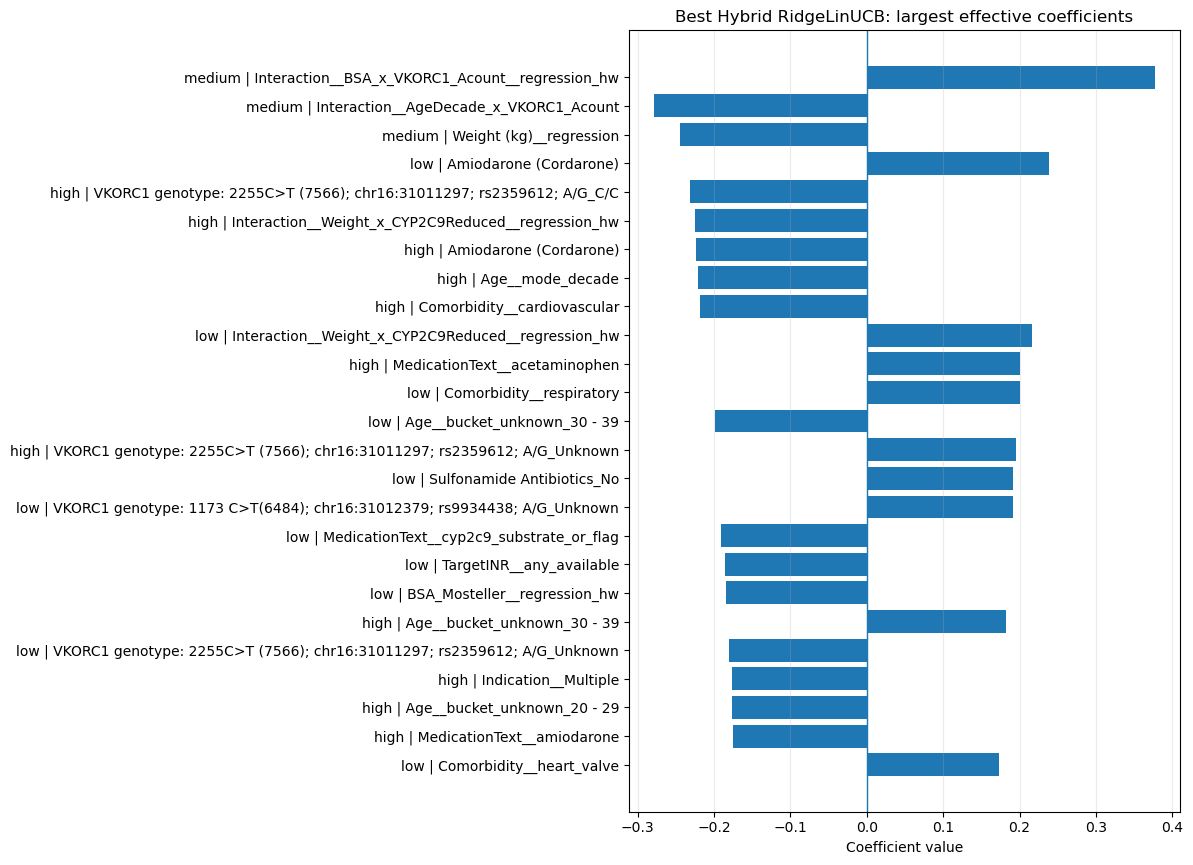

In [38]:
fig, ax = plot_top_coefficients(
    audits['best_hybrid_ridge_linucb']['top_coefficients'],
    title='Best Hybrid RidgeLinUCB: largest effective coefficients',
    top_n=25,
)
fig.savefig(AUDIT_DIR / 'best_hybrid_ridge_linucb_top_coefficients.png', dpi=180, bbox_inches='tight')
plt.show()